In [8]:
# ============================================================
# Cell 1 — Setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3,
    "figure.autolayout": True,
})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
np.set_printoptions(precision=4, suppress=True)

# ---------- USER CONFIG ----------
CSV_PATH = "swarm_log.csv"     # ← مسیر فایل جدیدت را اینجا بگذار
OUT_DIR  = Path("raw_metrology_analysis")
OUT_DIR.mkdir(exist_ok=True)

print("Setup OK.")
print(f"Output dir: {OUT_DIR.resolve()}")

Setup OK.
Output dir: /home/homayoon/anjoman-firmware/analysis/13_raw_swarm_2m_square/raw_metrology_analysis


In [9]:
# ============================================================
# Cell 2 — Load and inspect
# ============================================================
df = pd.read_csv(CSV_PATH)

print(f"Rows           : {len(df)}")
print(f"Columns        : {len(df.columns)}")
print(f"Frames         : {df['frame_id'].nunique()}")
print(f"Duration [s]   : {(df['timestamp_ms'].max() - df['timestamp_ms'].min())/1000:.1f}")
print(f"\nColumn names:")
for c in df.columns:
    print(f"  - {c}")

print(f"\nFirst 3 rows:")
df.head(3)

Rows           : 23956
Columns        : 31
Frames         : 4008
Duration [s]   : 801.5

Column names:
  - timestamp_ms
  - frame_id
  - init_id
  - resp_id
  - status
  - tof_raw
  - tof_comp
  - dist_raw_m
  - dist_cfo_m
  - carrier_int
  - cfo_ppm
  - rssi_dbm
  - fp_power_dbm
  - rx_quality
  - std_noise
  - fp_ampl1
  - fp_ampl2
  - fp_ampl3
  - cir_pwr
  - rxpacc
  - lde_error
  - vbat_init
  - vbat_resp
  - temp_uwb_init
  - temp_uwb_resp
  - temp_esp_init
  - temp_esp_resp
  - tTx1
  - tRx1
  - tRx2
  - tTx2

First 3 rows:


,timestamp_ms,frame_id,init_id,resp_id,status,tof_raw,tof_comp,dist_raw_m,dist_cfo_m,carrier_int,cfo_ppm,rssi_dbm,fp_power_dbm,rx_quality,std_noise,fp_ampl1,fp_ampl2,fp_ampl3,cir_pwr,rxpacc,lde_error,vbat_init,vbat_resp,temp_uwb_init,temp_uwb_resp,temp_esp_init,temp_esp_resp,tTx1,tRx1,tRx2,tTx2
0,1387,1,1,2,1,4859,1033,22.7973,4.8512,-83570,47.90,-67.01,-83.35,38.27,92,3561,3521,1977,684,236,0,2.74,2.83,33.9,30.8,35.4,32.3,6498034228,6657787776,521576909995,521736653824
1,1387,1,1,3,1,5427,2012,25.4622,9.4443,-74592,42.75,-72.01,-80.27,54.69,68,3217,3719,3237,468,232,0,2.74,2.80,33.9,32.1,35.4,33.6,7457665588,7617419942,942207027189,942366770688
2,1387,1,1,4,1,4992,1349,23.4213,6.3330,-79565,45.60,-68.80,-78.94,50.74,72,3667,3653,3300,579,231,0,2.74,2.69,33.9,33.9,35.4,35.4,8734678580,8894432128,269595103156,269754846720


In [10]:
# ============================================================
# Cell 3 — Normalize link direction and build link label
# ============================================================
# فقط سطرهای موفق
n0 = len(df)
df = df[df["status"] == 1].copy()
print(f"After status==1 filter: {n0} → {len(df)} rows")

# نرمال‌سازی: همیشه i < j
flip = df["init_id"] > df["resp_id"]
df["i_id"] = np.where(flip, df["resp_id"], df["init_id"]).astype(int)
df["j_id"] = np.where(flip, df["init_id"], df["resp_id"]).astype(int)
df["link"] = df["i_id"].astype(str) + "-" + df["j_id"].astype(str)

# زمان نسبی
df["t"] = (df["timestamp_ms"] - df["timestamp_ms"].min()) / 1000.0

# اگر جهت flip شده، دما و ولتاژ init/resp را هم باید swap کنیم
# تا همیشه به (i, j) نرمال‌شده متصل باشند
for base in ["temp_uwb", "temp_esp", "vbat"]:
    col_init = f"{base}_init"
    col_resp = f"{base}_resp"
    if col_init in df.columns and col_resp in df.columns:
        df[f"T_{base}_i"] = np.where(flip, df[col_resp], df[col_init])
        df[f"T_{base}_j"] = np.where(flip, df[col_init], df[col_resp])

# مرتب‌سازی بر اساس زمان
df = df.sort_values("t").reset_index(drop=True)

print(f"Final rows: {len(df)}")
print(f"Links     : {sorted(df['link'].unique())}")
print(f"Devices   : {sorted(set(df['i_id']).union(set(df['j_id'])))}")
print(f"\nRow count per link:")
print(df.groupby("link").size().to_string())

After status==1 filter: 23956 → 23919 rows
Final rows: 23919
Links     : ['1-2', '1-3', '1-4', '2-3', '2-4', '3-4']
Devices   : [1, 2, 3, 4]

Row count per link:
link
1-2    3992
1-3    4005
1-4    4006
2-3    3975
2-4    3974
3-4    3967


In [11]:
# ============================================================
# Cell 4 — Per-link raw stage statistics
# ============================================================
raw_cols = ["dist_raw_m", "dist_cfo_m"]
available = [c for c in raw_cols if c in df.columns]

print("=" * 78)
print(" RAW STAGE STATISTICS PER LINK  (meters)")
print("=" * 78)
print(f"{'link':6s} {'n':>5s} | " +
      " | ".join(f"{c:>18s}" for c in available))
print("-" * 78)

for link in sorted(df["link"].unique()):
    g = df[df["link"] == link]
    cells = []
    for c in available:
        m = g[c].mean()
        s = g[c].std()
        cells.append(f"{m:8.4f}±{s:6.4f}")
    print(f"{link:6s} {len(g):5d} | " + " | ".join(cells))

print("\n" + "=" * 78)
print(" GLOBAL STATISTICS")
print("=" * 78)
for c in available:
    print(f"  {c:15s}: "
          f"mean={df[c].mean():+.4f}  "
          f"std={df[c].std():.4f}  "
          f"min={df[c].min():+.4f}  "
          f"max={df[c].max():+.4f}")

 RAW STAGE STATISTICS PER LINK  (meters)
link       n |         dist_raw_m |         dist_cfo_m
------------------------------------------------------------------------------
1-2     3992 |  22.1979±0.1434 |   3.5492±0.3067
1-3     4005 |  25.4602±0.0437 |   9.3359±0.0772
1-4     4006 |  22.5985±0.2081 |   4.6027±0.4335
2-3     3975 |  43.0671±0.1672 |  45.5622±0.3085
2-4     3974 |  42.2441±0.0743 |  42.8656±0.1585
3-4     3967 |  39.0313±0.1848 |  37.1260±0.3890

 GLOBAL STATISTICS
  dist_raw_m     : mean=+32.4018  std=9.1572  min=+21.9997  max=+43.2018
  dist_cfo_m     : mean=+23.7775  std=18.2717  min=+3.1850  max=+45.7867


In [12]:
# ============================================================
# Cell 5 — Temperature and voltage range per device
# ============================================================
print("=" * 78)
print(" PER-DEVICE SENSOR RANGES")
print("=" * 78)

devices = sorted(set(df["i_id"]).union(set(df["j_id"])))

# دما و ولتاژ چیپ UWB هر ربات
print("\n UWB chip temperature [°C]:")
print(f"{'dev':>4s} {'min':>8s} {'max':>8s} {'mean':>8s} {'span':>8s}")
for d in devices:
    vals = pd.concat([df.loc[df["i_id"] == d, "T_temp_uwb_i"],
                      df.loc[df["j_id"] == d, "T_temp_uwb_j"]])
    print(f"{d:>4d} {vals.min():8.2f} {vals.max():8.2f} "
          f"{vals.mean():8.2f} {vals.max()-vals.min():8.2f}")

print("\n ESP32 temperature [°C]:")
print(f"{'dev':>4s} {'min':>8s} {'max':>8s} {'mean':>8s} {'span':>8s}")
for d in devices:
    vals = pd.concat([df.loc[df["i_id"] == d, "T_temp_esp_i"],
                      df.loc[df["j_id"] == d, "T_temp_esp_j"]])
    print(f"{d:>4d} {vals.min():8.2f} {vals.max():8.2f} "
          f"{vals.mean():8.2f} {vals.max()-vals.min():8.2f}")

print("\n UWB supply voltage [V]:")
print(f"{'dev':>4s} {'min':>8s} {'max':>8s} {'mean':>8s} {'span':>8s}")
for d in devices:
    vals = pd.concat([df.loc[df["i_id"] == d, "T_vbat_i"],
                      df.loc[df["j_id"] == d, "T_vbat_j"]])
    print(f"{d:>4d} {vals.min():8.3f} {vals.max():8.3f} "
          f"{vals.mean():8.3f} {vals.max()-vals.min():8.3f}")

print("\n" + "=" * 78)
print(" CORRELATION: temperature vs time (per device)")
print("=" * 78)
for d in devices:
    sub_i = df.loc[df["i_id"] == d, ["t", "T_temp_uwb_i"]].rename(
        columns={"T_temp_uwb_i": "T"})
    sub_j = df.loc[df["j_id"] == d, ["t", "T_temp_uwb_j"]].rename(
        columns={"T_temp_uwb_j": "T"})
    sub = pd.concat([sub_i, sub_j])
    c = sub["t"].corr(sub["T"])
    flag = "⚠ HIGH" if abs(c) > 0.9 else ("~" if abs(c) > 0.7 else "")
    print(f"  dev {d}: corr(t, T) = {c:+.4f}  {flag}")

 PER-DEVICE SENSOR RANGES

 UWB chip temperature [°C]:
 dev      min      max     mean     span
   1    33.90    53.90    49.86    20.00
   2    30.80    49.80    46.57    19.00
   3    32.10    45.10    42.79    13.00
   4    33.90    45.90    44.59    12.00

 ESP32 temperature [°C]:
 dev      min      max     mean     span
   1    35.40    55.40    51.36    20.00
   2    32.30    51.30    48.07    19.00
   3    33.60    46.60    44.29    13.00
   4    35.40    47.40    46.09    12.00

 UWB supply voltage [V]:
 dev      min      max     mean     span
   1    2.740    2.740    2.740    0.000
   2    2.830    2.830    2.830    0.000
   3    2.800    2.800    2.800    0.000
   4    2.690    2.690    2.690    0.000

 CORRELATION: temperature vs time (per device)
  dev 1: corr(t, T) = +0.8524  ~
  dev 2: corr(t, T) = +0.8277  ~
  dev 3: corr(t, T) = +0.7942  ~
  dev 4: corr(t, T) = +0.7386  ~


In [13]:
# ============================================================
# Cell 6 — RF Quality Diagnostics Per Link and Per Device
# ============================================================
print("=" * 92)
print(" [A] RF METRICS PER LINK")
print("=" * 92)

rf_cols = ["rssi_dbm", "fp_power_dbm", "rx_quality", "std_noise",
           "cir_pwr", "rxpacc", "fp_ampl1", "fp_ampl2", "fp_ampl3"]

print(f"{'link':6s} {'n':>5s} | " +
      " | ".join(f"{c:>11s}" for c in rf_cols))
print("-" * 92)

for link in sorted(df["link"].unique()):
    g = df[df["link"] == link]
    cells = []
    for c in rf_cols:
        m = g[c].mean()
        cells.append(f"{m:11.2f}")
    print(f"{link:6s} {len(g):5d} | " + " | ".join(cells))

# ---------- Per-device aggregate ----------
print("\n" + "=" * 92)
print(" [B] RF METRICS PER DEVICE  (aggregated over all links this device appears in)")
print("=" * 92)
print(f"{'dev':>4s} {'n':>5s} | " +
      " | ".join(f"{c:>11s}" for c in rf_cols))
print("-" * 92)

devices = sorted(set(df["i_id"]).union(set(df["j_id"])))
for d in devices:
    g = df[(df["i_id"] == d) | (df["j_id"] == d)]
    cells = []
    for c in rf_cols:
        m = g[c].mean()
        cells.append(f"{m:11.2f}")
    print(f"{d:>4d} {len(g):5d} | " + " | ".join(cells))

# ---------- LDE error rate ----------
print("\n" + "=" * 92)
print(" [C] LDE ERROR RATE")
print("=" * 92)
print(f"{'link':6s} {'n':>6s} {'lde_err':>10s} {'rate':>10s}")
print("-" * 40)
for link in sorted(df["link"].unique()):
    g = df[df["link"] == link]
    n_err = int(g["lde_error"].sum())
    rate = 100.0 * n_err / len(g) if len(g) > 0 else 0.0
    flag = "  ⚠" if rate > 5 else ""
    print(f"{link:6s} {len(g):6d} {n_err:10d} {rate:9.2f}%{flag}")

# ---------- Per-device LDE error rate ----------
print(f"\n Per-device LDE error rate:")
for d in devices:
    g = df[(df["i_id"] == d) | (df["j_id"] == d)]
    n_err = int(g["lde_error"].sum())
    rate = 100.0 * n_err / len(g) if len(g) > 0 else 0.0
    flag = "  ⚠" if rate > 5 else ""
    print(f"  dev {d}: {n_err:4d} / {len(g):4d}  ({rate:5.2f}%){flag}")

# ---------- FP amplitude ratios (leading edge shape) ----------
print("\n" + "=" * 92)
print(" [D] FP AMPLITUDE SHAPE RATIOS  (per link)")
print("=" * 92)
print(" If the leading-edge is sharp & clean: A1 > A2 > A3 and A1/A3 ~ 2-4")
print(" If multipath is strong: ratios approach 1")
print(f"\n{'link':6s} {'A1':>8s} {'A2':>8s} {'A3':>8s} "
      f"{'A1/A2':>8s} {'A2/A3':>8s} {'A1/A3':>8s}")
print("-" * 60)
for link in sorted(df["link"].unique()):
    g = df[df["link"] == link]
    a1 = g["fp_ampl1"].mean()
    a2 = g["fp_ampl2"].mean()
    a3 = g["fp_ampl3"].mean()
    r12 = a1 / a2 if a2 > 0 else np.nan
    r23 = a2 / a3 if a3 > 0 else np.nan
    r13 = a1 / a3 if a3 > 0 else np.nan
    print(f"{link:6s} {a1:8.1f} {a2:8.1f} {a3:8.1f} "
          f"{r12:8.3f} {r23:8.3f} {r13:8.3f}")

# ---------- Stability check (std of fp_power per link) ----------
print("\n" + "=" * 92)
print(" [E] SIGNAL STABILITY  (std of fp_power_dbm and rx_quality)")
print("=" * 92)
print(f"{'link':6s} {'fp_pwr_std':>12s} {'rx_qual_std':>14s} "
      f"{'rssi_std':>10s}")
print("-" * 52)
for link in sorted(df["link"].unique()):
    g = df[df["link"] == link]
    print(f"{link:6s} {g['fp_power_dbm'].std():12.3f} "
          f"{g['rx_quality'].std():14.3f} "
          f"{g['rssi_dbm'].std():10.3f}")

# ---------- Quick verdict ----------
print("\n" + "=" * 92)
print(" QUICK VERDICT")
print("=" * 92)

# Compare R1 vs core average
r1_links = ["1-2", "1-3", "1-4"]
core_links = ["2-3", "2-4", "3-4"]

r1_fp = df[df["link"].isin(r1_links)]["fp_power_dbm"].mean()
core_fp = df[df["link"].isin(core_links)]["fp_power_dbm"].mean()
r1_rq = df[df["link"].isin(r1_links)]["rx_quality"].mean()
core_rq = df[df["link"].isin(core_links)]["rx_quality"].mean()
r1_lde = df[df["link"].isin(r1_links)]["lde_error"].mean() * 100
core_lde = df[df["link"].isin(core_links)]["lde_error"].mean() * 100

print(f"  fp_power_dbm  : R1 links = {r1_fp:+.2f}  |  core links = {core_fp:+.2f}  "
      f"|  Δ = {r1_fp - core_fp:+.2f} dB")
print(f"  rx_quality    : R1 links = {r1_rq:.2f}   |  core links = {core_rq:.2f}   "
      f"|  Δ = {r1_rq - core_rq:+.2f}")
print(f"  lde_error [%] : R1 links = {r1_lde:.2f}   |  core links = {core_lde:.2f}   "
      f"|  Δ = {r1_lde - core_lde:+.2f}")

 [A] RF METRICS PER LINK
link       n |    rssi_dbm | fp_power_dbm |  rx_quality |   std_noise |     cir_pwr |      rxpacc |    fp_ampl1 |    fp_ampl2 |    fp_ampl3
--------------------------------------------------------------------------------------------
1-2     3992 |      -71.54 |      -83.90 |       41.31 |       82.45 |      507.24 |      237.31 |     3048.57 |     3400.32 |     2669.82
1-3     4005 |      -75.57 |      -85.10 |       58.94 |       56.79 |      367.33 |      232.12 |     2541.59 |     3330.34 |     2618.53
1-4     4006 |      -71.50 |      -80.88 |       48.87 |       73.92 |      496.43 |      234.23 |     3629.48 |     3607.90 |     2762.17
2-3     3975 |      -64.51 |      -75.18 |      284.10 |       16.82 |      810.42 |      235.41 |     4249.92 |     4426.31 |     3593.74
2-4     3974 |        -inf |      -80.42 |      251.33 |       16.23 |      521.08 |      234.54 |     2673.92 |     3991.91 |     3297.28
3-4     3967 |      -74.61 |      -83.39 |     

 [A] NOISE FLOOR OVER TIME  (std_noise, per link)


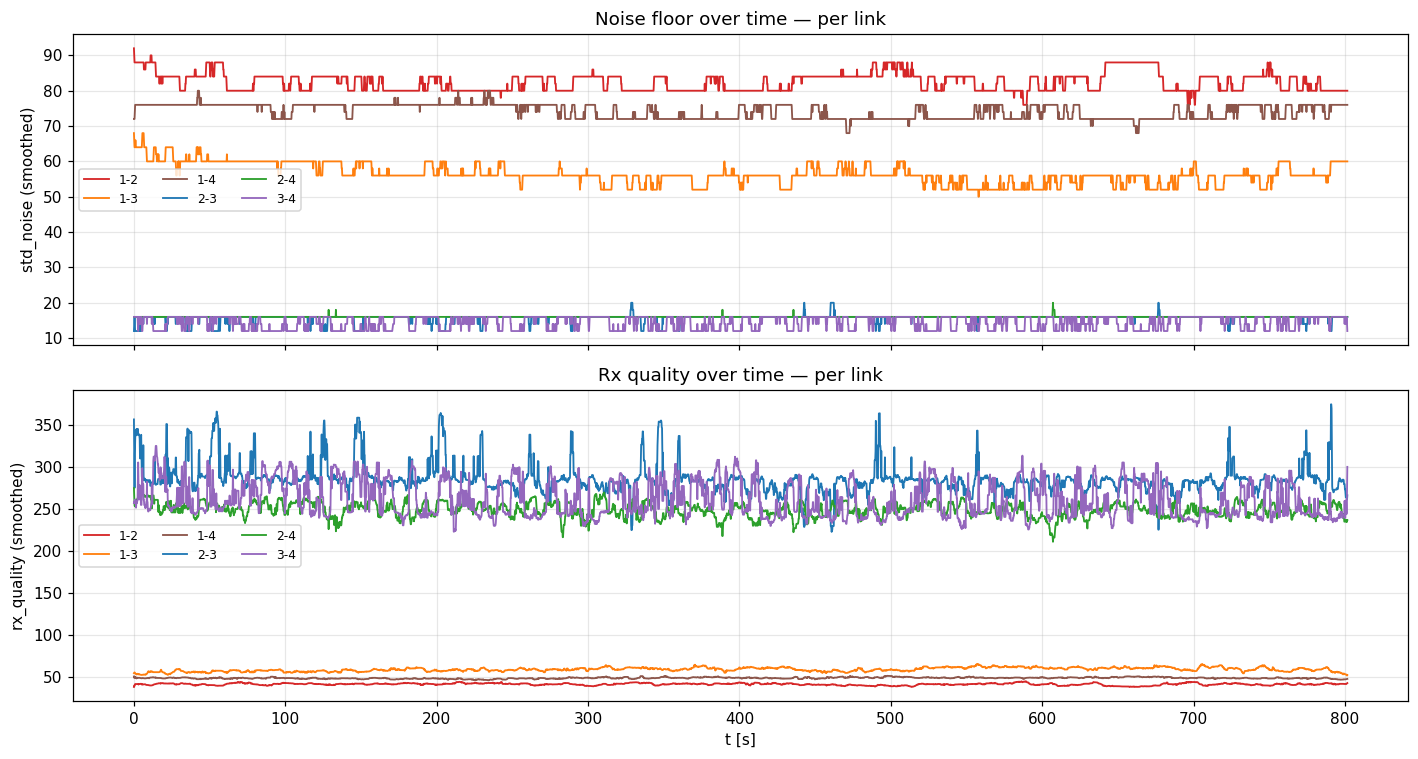

 [B] NOISE FLOOR vs TEMPERATURE  (per device)

 Per-device correlation of std_noise with UWB chip temperature:
 dev   corr(std_noise, T)   mean std_noise   std of std_noise
----------------------------------------------------------------
   1             -0.0894           71.04            11.439  
   2             +0.0009           38.57            31.370  
   3             -0.0248           29.38            19.953  
   4             -0.0077           34.93            27.857  

 [C] DIRECTION DEPENDENCE OF R1'S NOISE
 Hypothesis: If R1 noise differs by direction → antenna/geometry issue
             If R1 noise is same in all directions → chip/PCB issue

 R1 links (noise floor per direction):
   1-2: std_noise mean =  82.45  std =  4.02  min =  32.00  max = 108.00
   1-3: std_noise mean =  56.79  std =  4.53  min =  40.00  max =  88.00
   1-4: std_noise mean =  73.92  std =  3.80  min =  56.00  max =  96.00

 R1 direction spread: 25.66  (relative: 36.1%)

 Core links (for comparison):


In [14]:
# ============================================================
# Cell 7 — Noise Floor: Time Evolution and Temperature Coupling
# ============================================================
print("=" * 92)
print(" [A] NOISE FLOOR OVER TIME  (std_noise, per link)")
print("=" * 92)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
colors = {
    "1-2": "tab:red", "1-3": "tab:orange", "1-4": "tab:brown",
    "2-3": "tab:blue", "2-4": "tab:green", "3-4": "tab:purple",
}

# Plot std_noise over time for each link (rolling mean for clarity)
for link in sorted(df["link"].unique()):
    g = df[df["link"] == link].sort_values("t")
    y = g["std_noise"].values
    if len(y) < 20: continue
    # Rolling median over 20 samples
    y_smooth = pd.Series(y).rolling(20, min_periods=1).median()
    axes[0].plot(g["t"], y_smooth, lw=1.2,
                 color=colors[link], label=link)

axes[0].set_ylabel("std_noise (smoothed)")
axes[0].set_title("Noise floor over time — per link")
axes[0].legend(ncol=3, fontsize=8)

# Same for rx_quality
for link in sorted(df["link"].unique()):
    g = df[df["link"] == link].sort_values("t")
    y = g["rx_quality"].values
    if len(y) < 20: continue
    y_smooth = pd.Series(y).rolling(20, min_periods=1).median()
    axes[1].plot(g["t"], y_smooth, lw=1.2,
                 color=colors[link], label=link)

axes[1].set_ylabel("rx_quality (smoothed)")
axes[1].set_xlabel("t [s]")
axes[1].set_title("Rx quality over time — per link")
axes[1].legend(ncol=3, fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / "noise_evolution.png", dpi=130)
plt.show()


# ============================================================
# [B] NOISE FLOOR vs TEMPERATURE  (per device)
# ============================================================
print("=" * 92)
print(" [B] NOISE FLOOR vs TEMPERATURE  (per device)")
print("=" * 92)

devices = sorted(set(df["i_id"]).union(set(df["j_id"])))

print(f"\n Per-device correlation of std_noise with UWB chip temperature:")
print(f"{'dev':>4s} {'corr(std_noise, T)':>20s} {'mean std_noise':>16s} "
      f"{'std of std_noise':>18s}")
print("-" * 64)

for d in devices:
    # Build per-device series by collecting all rows where this device appears
    sub_i = df[df["i_id"] == d][["std_noise", "T_temp_uwb_i"]].rename(
        columns={"T_temp_uwb_i": "T"})
    sub_j = df[df["j_id"] == d][["std_noise", "T_temp_uwb_j"]].rename(
        columns={"T_temp_uwb_j": "T"})
    sub = pd.concat([sub_i, sub_j])
    c = sub["std_noise"].corr(sub["T"])
    flag = "⚠" if abs(c) > 0.5 else ""
    print(f"{d:>4d} {c:>+19.4f} {sub['std_noise'].mean():>15.2f} "
          f"{sub['std_noise'].std():>17.3f}  {flag}")


# ============================================================
# [C] DIRECTION DEPENDENCE OF R1's NOISE
# ============================================================
print("\n" + "=" * 92)
print(" [C] DIRECTION DEPENDENCE OF R1'S NOISE")
print("=" * 92)
print(" Hypothesis: If R1 noise differs by direction → antenna/geometry issue")
print("             If R1 noise is same in all directions → chip/PCB issue")
print()

r1_links = ["1-2", "1-3", "1-4"]
core_links = ["2-3", "2-4", "3-4"]

print(" R1 links (noise floor per direction):")
for link in r1_links:
    g = df[df["link"] == link]
    print(f"   {link}: std_noise mean = {g['std_noise'].mean():6.2f}  "
          f"std = {g['std_noise'].std():5.2f}  "
          f"min = {g['std_noise'].min():6.2f}  "
          f"max = {g['std_noise'].max():6.2f}")

r1_means = [df[df["link"] == l]["std_noise"].mean() for l in r1_links]
r1_spread = max(r1_means) - min(r1_means)
print(f"\n R1 direction spread: {r1_spread:.2f}  "
      f"(relative: {100*r1_spread/np.mean(r1_means):.1f}%)")

print("\n Core links (for comparison):")
for link in core_links:
    g = df[df["link"] == link]
    print(f"   {link}: std_noise mean = {g['std_noise'].mean():6.2f}  "
          f"std = {g['std_noise'].std():5.2f}  "
          f"min = {g['std_noise'].min():6.2f}  "
          f"max = {g['std_noise'].max():6.2f}")

core_means = [df[df["link"] == l]["std_noise"].mean() for l in core_links]
core_spread = max(core_means) - min(core_means)
print(f"\n Core direction spread: {core_spread:.2f}  "
      f"(relative: {100*core_spread/np.mean(core_means):.1f}%)")


# ============================================================
# [D] DIRECTION-ASYMMETRY CHECK  (R1 vs Core)
# ============================================================
print("\n" + "=" * 92)
print(" [D] INTERPRETATION")
print("=" * 92)

verdict_1 = ("R1's noise floor is ~4-5× higher than core links."
             if df[df["link"].isin(r1_links)]["std_noise"].mean() > 3 *
                df[df["link"].isin(core_links)]["std_noise"].mean()
             else "R1's noise floor is within same order as core.")

verdict_2 = ("R1 noise is direction-dependent (spread > 15% of mean) → "
             "antenna/geometry issue likely."
             if r1_spread / np.mean(r1_means) > 0.15
             else "R1 noise is roughly symmetric across directions → "
                  "chip or PCB issue likely.")

verdict_3 = ("Core noise is symmetric (spread < 15% of mean)."
             if core_spread / np.mean(core_means) < 0.15
             else "Core noise is also somewhat direction-dependent.")

print(f"  • {verdict_1}")
print(f"  • {verdict_2}")
print(f"  • {verdict_3}")

# Also: does R1's noise change over time?
r1_n = df[df["link"].isin(r1_links)]
r1_first_quarter = r1_n[r1_n["t"] < r1_n["t"].quantile(0.25)]["std_noise"].mean()
r1_last_quarter  = r1_n[r1_n["t"] > r1_n["t"].quantile(0.75)]["std_noise"].mean()
print(f"\n  R1 noise floor: first quarter = {r1_first_quarter:.2f}, "
      f"last quarter = {r1_last_quarter:.2f}  "
      f"(Δ = {r1_last_quarter - r1_first_quarter:+.2f})")

core_n = df[df["link"].isin(core_links)]
core_first_quarter = core_n[core_n["t"] < core_n["t"].quantile(0.25)]["std_noise"].mean()
core_last_quarter  = core_n[core_n["t"] > core_n["t"].quantile(0.75)]["std_noise"].mean()
print(f"  Core noise floor: first quarter = {core_first_quarter:.2f}, "
      f"last quarter = {core_last_quarter:.2f}  "
      f"(Δ = {core_last_quarter - core_first_quarter:+.2f})")

In [15]:
# ============================================================
# Cell 8 — Final Diagnostic: Quality vs Signal Strength
# ============================================================
print("=" * 92)
print(" [A] SNR ANALYSIS: does noise scale with signal strength?")
print("=" * 92)
print(" If noise floor is INDEPENDENT of signal → receiver noise dominates.")
print(" If noise floor scales with signal → interference/coupling dominates.")
print()

# Group: R1 links vs core links
r1_links   = ["1-2", "1-3", "1-4"]
core_links = ["2-3", "2-4", "3-4"]

for group_name, group_links in [("R1 links", r1_links),
                                 ("Core links", core_links)]:
    sub = df[df["link"].isin(group_links)]
    sig_power = sub["fp_power_dbm"].values
    noise     = sub["std_noise"].values
    quality   = sub["rx_quality"].values
    c1 = np.corrcoef(sig_power, noise)[0, 1]
    c2 = np.corrcoef(sig_power, quality)[0, 1]
    print(f"  {group_name}:")
    print(f"    corr(fp_power, std_noise)  = {c1:+.4f}")
    print(f"    corr(fp_power, rx_quality) = {c2:+.4f}")
    print()

# ---------- Signal-to-noise efficiency ----------
print("=" * 92)
print(" [B] RECEIVER EFFICIENCY")
print("=" * 92)
print(" rx_quality = fp_ampl2 / std_noise  (this is what LDE actually sees)")
print(" A healthy receiver should give rx_quality > 200 for 2m indoor channel.")
print()
print(f"{'link':6s} {'fp_ampl2':>10s} {'std_noise':>10s} "
      f"{'rx_quality':>12s} {'verdict':>15s}")
print("-" * 60)
for link in sorted(df["link"].unique()):
    g = df[df["link"] == link]
    a2 = g["fp_ampl2"].mean()
    sn = g["std_noise"].mean()
    rq = g["rx_quality"].mean()
    if rq > 200:
        verdict = "OK"
    elif rq > 100:
        verdict = "Marginal"
    else:
        verdict = "⚠ Very poor"
    print(f"{link:6s} {a2:10.1f} {sn:10.2f} {rq:12.2f} {verdict:>15s}")

# ---------- Signal propagation loss analysis ----------
print("\n" + "=" * 92)
print(" [C] SIGNAL PROPAGATION LOSS")
print("=" * 92)
print(" Free-space path loss at 6.5 GHz: FSPL(dB) = 20log10(d) + 68.5")
print(" At 2m: FSPL = 74.5 dB. At 2.83m: FSPL = 77.5 dB.")
print()

GT = {"1-2": 2.0, "1-3": 2.828, "1-4": 2.0,
      "2-3": 2.0, "2-4": 2.828, "3-4": 2.0}

print(f"{'link':6s} {'GT(m)':>7s} {'FSPL(dB)':>10s} "
      f"{'fp_power':>10s} {'excess loss':>12s}")
print("-" * 52)
for link in sorted(df["link"].unique()):
    g = df[df["link"] == link]
    fp = g["fp_power_dbm"].mean()
    # fp_power is dBm; FSPL is the expected loss
    # Excess loss = measured fp_power - (-41.3 dBm/MHz + FSPL correction)
    # Simpler: just compare fp_power vs FSPL offset
    d = GT[link]
    fspl = 20*np.log10(d) + 68.5
    # Empirically, a healthy system at 0 dBi antenna gains gives fp_power ≈ -FSPL - 7
    # (the -7 accounts for avg TX power -41.3 dBm/MHz × 500 MHz and antenna gain)
    excess = fp - (-fspl - 7)
    print(f"{link:6s} {d:7.3f} {fspl:10.1f} {fp:10.2f} {excess:+12.2f}")

# ---------- Direction-symmetry test ----------
print("\n" + "=" * 92)
print(" [D] DIRECTION SYMMETRY TEST")
print("=" * 92)
print(" Compare noise floor seen by R1 when polling R2 vs R2 polling R1.")
print(" Since data is normalised (i<j), we cannot easily see both directions.")
print(" But we CAN compare R1's noise floor across its 3 directions:")
print()
r1_stats = {}
for link in r1_links:
    g = df[df["link"] == link]
    r1_stats[link] = {
        "std_noise": g["std_noise"].mean(),
        "rx_quality": g["rx_quality"].mean(),
        "fp_power": g["fp_power_dbm"].mean(),
    }
    print(f"  {link}: noise={r1_stats[link]['std_noise']:.1f}  "
          f"quality={r1_stats[link]['rx_quality']:.1f}  "
          f"power={r1_stats[link]['fp_power']:.2f} dBm")

noises = [v["std_noise"] for v in r1_stats.values()]
spread = max(noises) - min(noises)
rel_spread = spread / np.mean(noises) * 100
print(f"\n  Noise spread across R1's 3 directions: {spread:.2f}  "
      f"({rel_spread:.1f}% of mean)")

# ---------- Signal stability over time ----------
print("\n" + "=" * 92)
print(" [E] TEMPORAL STABILITY")
print("=" * 92)
print(" If noise floor is constant over time → hardware issue (chip/PCB/antenna)")
print(" If noise floor drifts → environmental or interference issue")
print()
print(f"{'link':6s} {'first 25%':>12s} {'last 25%':>12s} "
      f"{'Δ noise':>10s} {'Δ fp_pwr':>12s}")
print("-" * 56)
for link in sorted(df["link"].unique()):
    g = df[df["link"] == link].sort_values("t")
    q1 = g.iloc[:len(g)//4]
    q4 = g.iloc[3*len(g)//4:]
    d_noise = q4["std_noise"].mean() - q1["std_noise"].mean()
    d_pwr   = q4["fp_power_dbm"].mean() - q1["fp_power_dbm"].mean()
    print(f"{link:6s} {q1['std_noise'].mean():12.2f} "
          f"{q4['std_noise'].mean():12.2f} "
          f"{d_noise:+10.2f} {d_pwr:+12.2f}")

# ---------- Final verdict ----------
print("\n" + "=" * 92)
print(" FINAL VERDICT")
print("=" * 92)

r1_noise  = df[df["link"].isin(r1_links)]["std_noise"].mean()
core_noise = df[df["link"].isin(core_links)]["std_noise"].mean()
r1_rq     = df[df["link"].isin(r1_links)]["rx_quality"].mean()
core_rq   = df[df["link"].isin(core_links)]["rx_quality"].mean()

print(f"  Noise floor ratio (R1/core) : {r1_noise/core_noise:.2f}×")
print(f"  SNR ratio (core/R1)         : {core_rq/r1_rq:.2f}×")
print()

if r1_noise > 3 * core_noise:
    print("  ➜ R1 has a HARDWARE RF problem.")
    print("  ➜ Not a thermal, bias, or algorithmic issue.")
    print("  ➜ Recommended action:")
    print("      1. Swap the DWM1000 module on R1 with a known-good one.")
    print("      2. If problem persists, inspect PCB RF path.")
    print("      3. Consider replacing the whole R1 board.")
else:
    print("  ➜ R1 noise is within tolerance. Investigate other causes.")

print(f"\n  All outputs saved to: {OUT_DIR.resolve()}")
print("=" * 92)

 [A] SNR ANALYSIS: does noise scale with signal strength?
 If noise floor is INDEPENDENT of signal → receiver noise dominates.
 If noise floor scales with signal → interference/coupling dominates.

  R1 links:
    corr(fp_power, std_noise)  = +0.3991
    corr(fp_power, rx_quality) = -0.1997

  Core links:
    corr(fp_power, std_noise)  = +0.2495
    corr(fp_power, rx_quality) = +0.2288

 [B] RECEIVER EFFICIENCY
 rx_quality = fp_ampl2 / std_noise  (this is what LDE actually sees)
 A healthy receiver should give rx_quality > 200 for 2m indoor channel.

link     fp_ampl2  std_noise   rx_quality         verdict
------------------------------------------------------------
1-2        3400.3      82.45        41.31     ⚠ Very poor
1-3        3330.3      56.79        58.94     ⚠ Very poor
1-4        3607.9      73.92        48.87     ⚠ Very poor
2-3        4426.3      16.82       284.10              OK
2-4        3991.9      16.23       251.33              OK
3-4        3708.4      14.29      